# Preprocesamiento del Dataset Breast Cancer Wisconsin

César Eduardo Jardines Mendoza Cuatrimestre III-2026 CICESE

## Descripción

Para esta tarea se definió usar los tipos de procesamiento aumento de datos SMOTE (Synthetic Minority Over-sampling Technique) y reducción de dimensionalidad (PCA).

Los datos vienen de los Hospitales de la Universidad de Wisconsin, recolectados por el médico William H. Wolberg entre 1989 y 1991. Son casos clínicos reales de citología de mama. Consta de 699 instancias y 11 columnas:


| # | Attribute | Domain |
|---|---|---|
| 1 | Sample code number | ID number |
| 2 | Clump Thickness | 1 - 10 |
| 3 | Uniformity of Cell Size | 1 - 10 |
| 4 | Uniformity of Cell Shape | 1 - 10 |
| 5 | Marginal Adhesion | 1 - 10 |
| 6 | Single Epithelial Cell Size | 1 - 10 |
| 7 | Bare Nuclei | 1 - 10 |
| 8 | Bland Chromatin | 1 - 10 |
| 9 | Normal Nucleoli | 1 - 10 |
| 10 | Mitoses | 1 - 10 |
| 11 | Class | 2 = Benign, 4 = Malignant |


- **Sample code number:** identificador de la muestra (no se usa en el análisis).
- **9 atributos citológicos** (Clump Thickness, Uniformity of Cell Size, Uniformity of Cell Shape, Marginal Adhesion, Single Epithelial Cell Size, Bare Nuclei, Bland Chromatin, Normal Nucleoli y Mitoses), evaluados en una escala entera del 1 al 10.
- **Class:** diagnóstico, codificado como 2 (benigno) y 4 (maligno).

Según el archivo `.names` existen 16 valores faltantes marcados con `?` en algunas filas del `.data`, en lugar de un número del 1 al 10 aparece un signo de interrogación. Significa que ese dato no se registró. Además menciona que la distribución de clases está desbalanceada con 458 filas benignas (65.5 %) y 241 filas malignas (34.5 %). Como observación hay casi dos benignos por cada maligno.

Como **primer paso** vamos a cargar el archivo `.data` y ver si lo que dice la documentación coincide. Como se mencionó que `?` denota los valores faltantes, entonces usaremos el parámetro `na_values="?"` para decirle a pandas que no es texto es un dato faltante.

In [2]:
import pandas as pd
import numpy as np

# Columnas identificadas
columnas = ["id", "clump_thickness", "uniformity_cell_size", "uniformity_cell_shape",
            "marginal_adhesion", "single_epithelial_cell_size", "bare_nuclei",
            "bland_chromatin", "normal_nucleoli", "mitoses", "class"]

# Lectura del archivo
df = pd.read_csv("breast-cancer-wisconsin.data", header=None,
                 names=columnas, na_values="?")

# Tupla que representa la dimensionalidad del DataFrame.
print(f'Dimensionalidad \n',df.shape)
df.info()
# Visualizamos las primeras filas del dataframe
df.head()

Dimensionalidad 
 (699, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           699 non-null    int64  
 1   clump_thickness              699 non-null    int64  
 2   uniformity_cell_size         699 non-null    int64  
 3   uniformity_cell_shape        699 non-null    int64  
 4   marginal_adhesion            699 non-null    int64  
 5   single_epithelial_cell_size  699 non-null    int64  
 6   bare_nuclei                  683 non-null    float64
 7   bland_chromatin              699 non-null    int64  
 8   normal_nucleoli              699 non-null    int64  
 9   mitoses                      699 non-null    int64  
 10  class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


Concluimos que el dataset tiene 699 registros y 11 columnas, lo que coincide con la documentación. Todas las columnas son enteras excepto `bare_nuclei`, que aparece como `float64` con 683 valores no nulos. Esto confirma la presencia de 16 valores faltantes en esa variable.

Como **segundo paso** lo que haremos es limpiar los datos, el motivo es que para aplicar las técnicas no debemos tener valores faltantes por lo que los 16 faltantes tienen que resolverse. Los problemas a corregir se identificaron a partir de la documentación `.names` y de la inspección inicial del DataFrame.


In [3]:
# Se trabaja sobre una copia para no alterar los datos originales
df_limpio = df.copy()

# Identificamos si hay datos duplicados y los eliminamos
print("Duplicados exactos:", df_limpio.duplicated().sum())
df_limpio = df_limpio.drop_duplicates()

# Eliminamos la columna id
df_limpio = df_limpio.drop(columns="id")

# Llenamos los faltantes de bare_nuclei con la mediana calculada
mediana = df_limpio["bare_nuclei"].median()
print("Mediana de bare_nuclei:", mediana)
df_limpio["bare_nuclei"] = df_limpio["bare_nuclei"].fillna(mediana).astype(int)

# Recodificamos la clase: 0 = benigno y 1 = maligno en lugar de 2 y 4
df_limpio["class"] = df_limpio["class"].map({2: 0, 4: 1})

# Verificamos que todo se haya aplicado correctamente
print(df_limpio.shape)
print("Faltantes restantes:", df_limpio.isnull().sum().sum())
print(df_limpio["class"].value_counts())

Duplicados exactos: 8
Mediana de bare_nuclei: 1.0
(691, 10)
Faltantes restantes: 0
class
0    453
1    238
Name: count, dtype: int64



- Se identificaron y eliminaron **8 registros duplicados** (idénticos incluyendo el identificador de muestra).
- Se eliminó la columna `id`, por no aportar información clínica.
- Los 16 valores faltantes de `bare_nuclei` se imputaron con la **mediana (1)**, respetando la escala entera de 1 a 10.
- La variable objetivo se recodificó como 0 = benigno y 1 = maligno.

El dataset ahora contiene **691 registros y 10 columnas**.

Como **tercer paso** vamos a ver qué observaciones podemos tener con los datos previamente limpios. La idea es mostrar cómo se distribuye cada variable, qué tan balanceadas están las clases a pesar de que ya el documento `.names` lo menciona, qué diferencias existen entre casos benignos y malignos, y qué relación guardan las variables entre sí.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizamos las columnas excluyendo a 'class'
variables = df_limpio.columns.drop("class")

# Mostramos la tabla
df_limpio[variables].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
clump_thickness,691.0,4.43,2.82,1.0,2.0,4.0,6.0,10.0
uniformity_cell_size,691.0,3.13,3.04,1.0,1.0,1.0,5.0,10.0
uniformity_cell_shape,691.0,3.20,2.96,1.0,1.0,1.0,5.0,10.0
marginal_adhesion,691.0,2.82,2.87,1.0,1.0,1.0,4.0,10.0
single_epithelial_cell_size,691.0,3.21,2.20,1.0,2.0,2.0,4.0,10.0
bare_nuclei,691.0,3.48,3.62,1.0,1.0,1.0,5.0,10.0
bland_chromatin,691.0,3.44,2.44,1.0,2.0,3.0,5.0,10.0
normal_nucleoli,691.0,2.88,3.07,1.0,1.0,1.0,4.0,10.0
mitoses,691.0,1.59,1.72,1.0,1.0,1.0,1.0,10.0


De acuerdo a la tabla obtenida podemos leerla de la siguiente forma:
- **count**: cuántos valores tiene la variable, podemos ver que no hay faltantes.
- **mean**: el promedio.
- **std**: qué tan dispersos están los valores alrededor del promedio.
- **min**: El valor más bajo.
- **25%**: significa que una cuarta parte de los pacientes tiene ese valor o menos.
- **50%**: es la mediana.
- **max**: es el valor más alto.

Los datos no presentan huecos o vacíos y se encuentran dentro del rango, no hay faltantes, el rango va de 1 a 10 y no hay valores raros como 11 u otro número distintos del 1 a 10.

Observamos que las distribuciones tienen valores bajos, `mitoses` casi no varía en sus datos, `clump_thickness` es la variable más equilibrada (media 4.43, mediana 4). La desviación estándar varía entre 1.72 y 3.62, por lo que, aunque todas las variables comparten escala, no aportan la misma cantidad de variación.



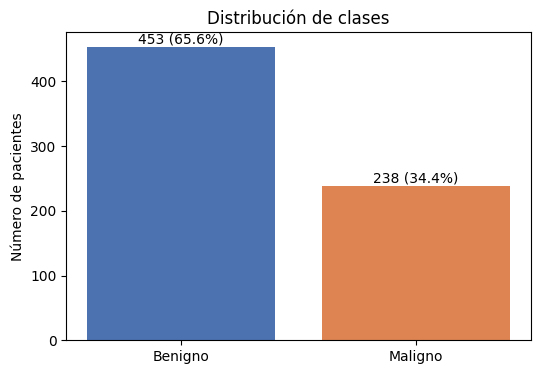

In [5]:
# Definimos un nombre a los valores 0 y 1
etiquetas = df_limpio["class"].map({0: "Benigno", 1: "Maligno"})
# Realizamos el conteo de pacientes por cada clase
conteo = etiquetas.value_counts()

# Definimos y construimos el histograma
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(conteo.index, conteo.values, color=["#4C72B0", "#DD8452"])

for i, v in enumerate(conteo.values):
    ax.text(i, v + 5, f"{v} ({v / len(df_limpio):.1%})", ha="center")
ax.set_title("Distribución de clases")
ax.set_ylabel("Número de pacientes")
plt.show()

Ahora veremos la distribución de los casos por clase

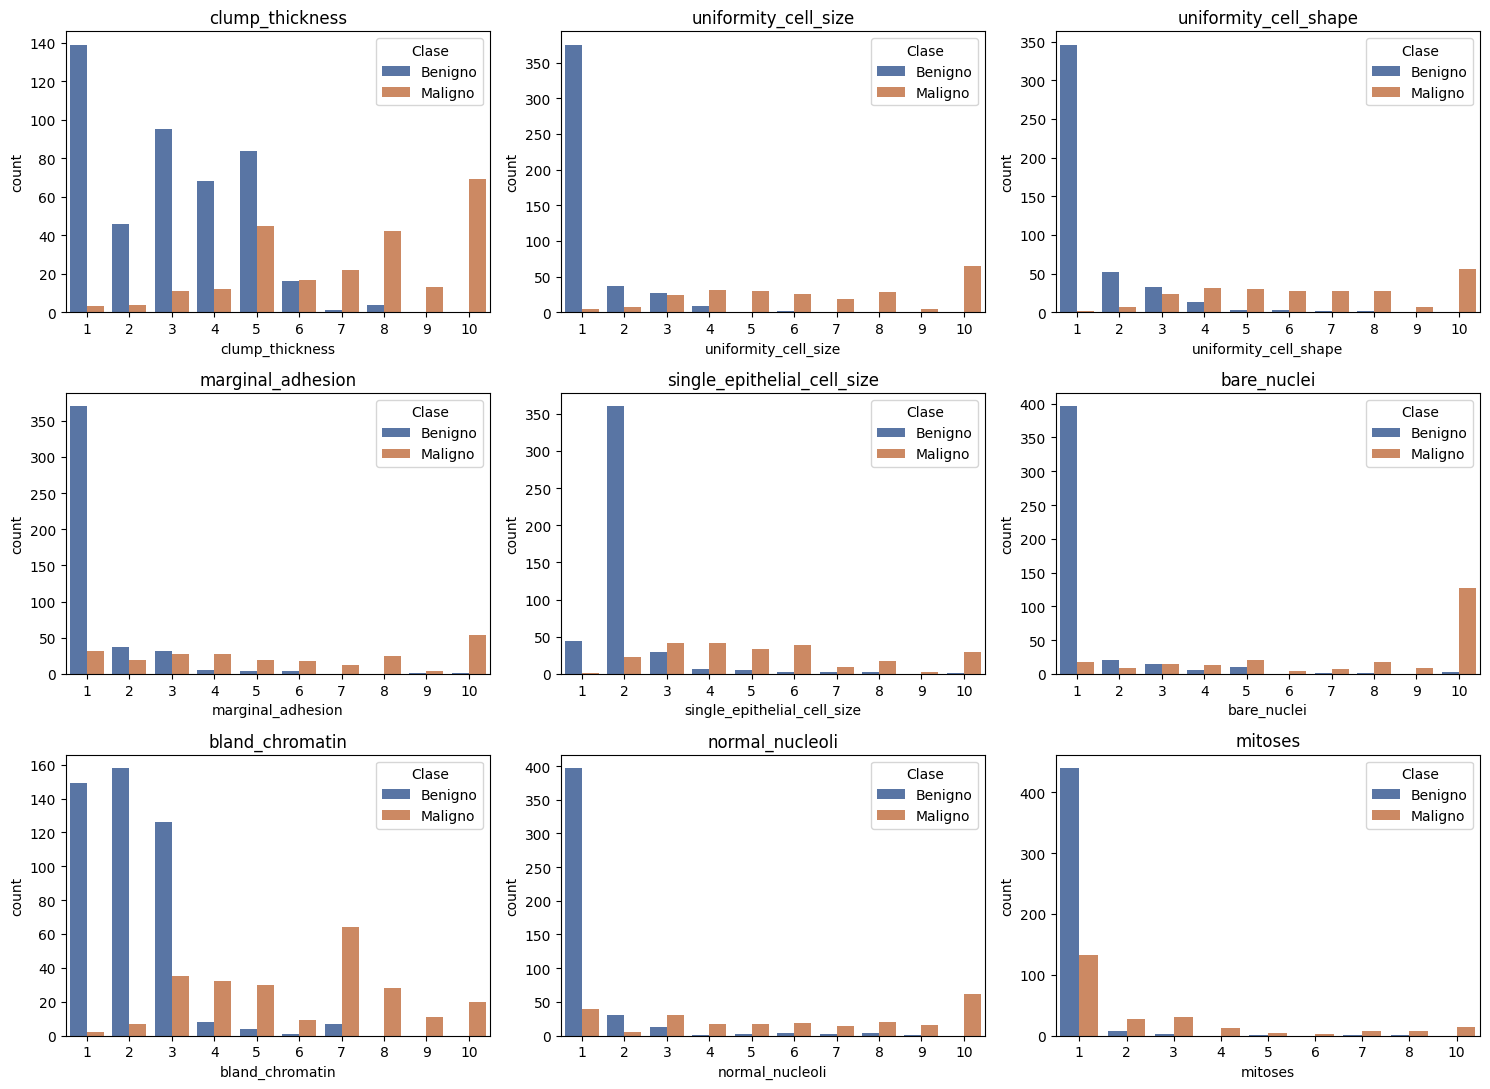

In [6]:

# Definimos y construimos los histogramas por clase
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, var in zip(axes.flat, variables):
    sns.countplot(data=df_limpio, x=var, hue="class",
                  palette=["#4C72B0", "#DD8452"], ax=ax)
    ax.set_title(var)
    ax.legend(title="Clase", labels=["Benigno", "Maligno"])
plt.tight_layout()
plt.show()

Podemos observar los siguientes patrones:

- Los casos benignos son uniformes en casi todas las clases
- Los malignos son variados, no siguen un patrón tan definido como el caso de benignos
- `uniformity_cell_size` y `uniformity_cell_shape` presentan distribuciones casi idénticas

Por último vamos a ver la correlación entre las variables con un mapa de calor siguiendo la correlación de Pearson. A primera vista podemos observar que las correlaciones son positivas, van de los valores 0.34 a 0.91.

Entre variables existe redundancia.

- `uniformity_cell_size` y `uniformity_cell_shape` (0.91) es el par más fuerte.
- `clump_thickness` está algo más separada del grupo (0.49 a 0.65).
- `mitoses` es la más independiente: su fila entera tiene tonos claros (0.34 a 0.48)

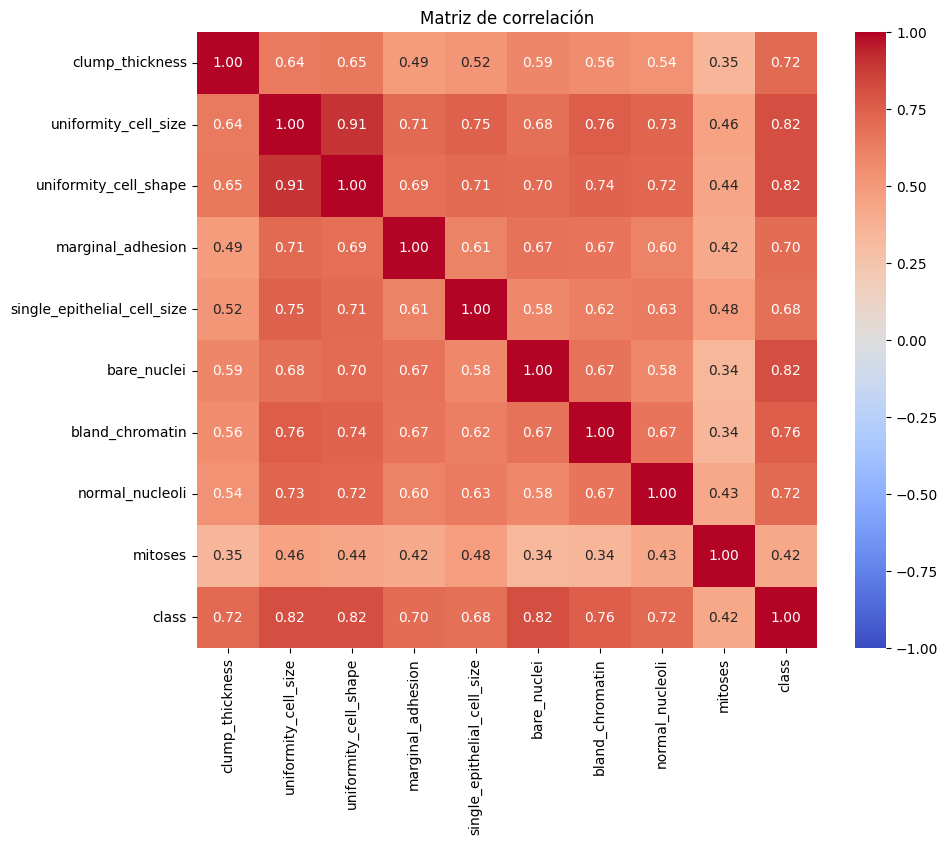

In [8]:
# Definimos y construimos el mapa de calor por variables
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_limpio.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación")
plt.show()

## Reducción de dimensionalidad con PCA

El Análisis de Componentes Principales (PCA) transforma las variables originales en un nuevo conjunto de variables llamadas componentes principales, que son combinaciones lineales de las originales. Los componentes se ordenan según la cantidad de variación de los datos que capturan. El primero captura la mayor parte, el segundo la mayor parte de lo que queda, y así sucesivamente.

En el análisis exploratorio las variables del dataset están fuertemente correlacionadas, por lo que parte de la información es redundante. Para hacer posible tener una mejor visualización necesitamos representar en dos dimensiones el dataset que originalmente tiene nueve. PCA permite resumir esa información en pocas dimensiones.


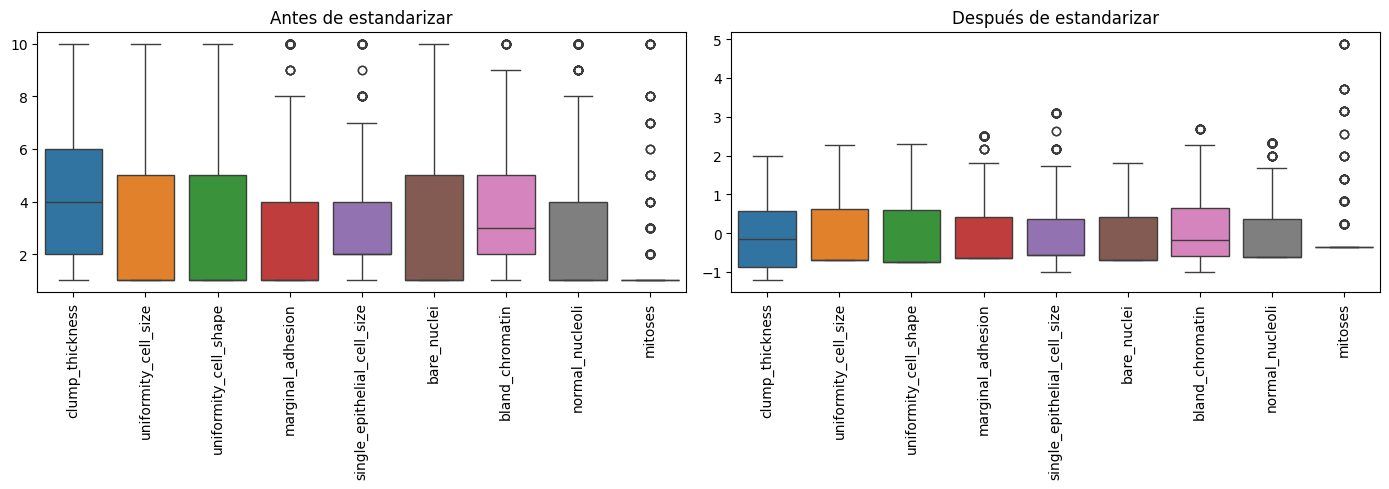

      clump_thickness  uniformity_cell_size  uniformity_cell_shape  \
mean             -0.0                   0.0                    0.0   
std               1.0                   1.0                    1.0   

      marginal_adhesion  single_epithelial_cell_size  bare_nuclei  \
mean                0.0                          0.0          0.0   
std                 1.0                          1.0          1.0   

      bland_chromatin  normal_nucleoli  mitoses  
mean              0.0              0.0      0.0  
std               1.0              1.0      1.0  


In [9]:
from sklearn.preprocessing import StandardScaler

# Separamos las variables predictoras (X) de la etiqueta (y)
X = df_limpio[variables]
y = df_limpio["class"]

# Creamos el estandarizador y lo aplicamos a cada variable le resta su media
# y la divide entre su desviación estándar
scaler = StandardScaler()
X_esc = scaler.fit_transform(X)

# Convertimos el resultado (un arreglo de NumPy) en DataFrame para conservar los nombres
X_esc = pd.DataFrame(X_esc, columns=variables, index=X.index)

# Comparamos visualmente la distribución de cada variable antes y después de estandarizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=X, ax=axes[0])
axes[0].set_title("Antes de estandarizar")
axes[0].tick_params(axis="x", rotation=90)

sns.boxplot(data=X_esc, ax=axes[1])
axes[1].set_title("Después de estandarizar")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

# Cada variable debe tener media 0 y desviación 1
print(X_esc.agg(["mean", "std"]).round(2))

Con la estandarización, todas las variables tienen media 0 y desviación estándar 1, evitando así que las variables con mayor dispersión dominen el análisis de PCA solo por su escala. La forma de las distribuciones se conserva ya que la transformación únicamente desplaza y reescala los valores.

Componente  Varianza explicada (%)  Varianza acumulada (%)
       PC1                    65.6                    65.6
       PC2                     8.6                    74.2
       PC3                     6.0                    80.2
       PC4                     5.2                    85.4
       PC5                     4.1                    89.5
       PC6                     3.3                    92.8
       PC7                     3.3                    96.1
       PC8                     2.9                    99.0
       PC9                     1.0                   100.0


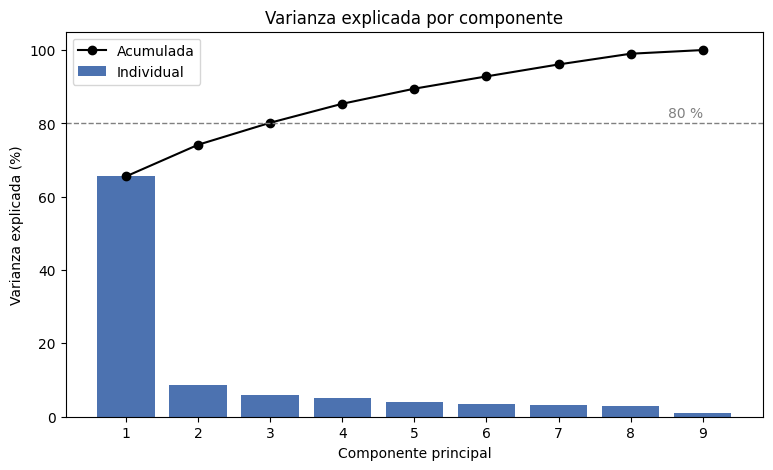

In [10]:
from sklearn.decomposition import PCA

# Ajusta PCA sin limitar componentes: calcula los 9 posibles
pca_completo = PCA()
pca_completo.fit(X_esc)

# Proporción de la varianza total que explica cada componente
varianza = pca_completo.explained_variance_ratio_

# Varianza acumulada: cuánto explican en conjunto los primeros k componentes
varianza_acum = np.cumsum(varianza)

# Tabla resumen, con porcentajes
tabla_varianza = pd.DataFrame({
    "Componente": [f"PC{i}" for i in range(1, len(varianza) + 1)],
    "Varianza explicada (%)": (varianza * 100).round(1),
    "Varianza acumulada (%)": (varianza_acum * 100).round(1)
})
print(tabla_varianza.to_string(index=False))

# Gráfica: barras para cada componente y línea para el acumulado
componentes = np.arange(1, len(varianza) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(componentes, varianza * 100, color="#4C72B0", label="Individual")
ax.plot(componentes, varianza_acum * 100, marker="o", color="black", label="Acumulada")

# Línea de referencia en 80 %, un umbral comúnmente usado
ax.axhline(80, color="gray", linestyle="--", linewidth=1)
ax.text(9, 81.5, "80 %", ha="right", color="gray")

ax.set_xticks(componentes)
ax.set_xlabel("Componente principal")
ax.set_ylabel("Varianza explicada (%)")
ax.set_title("Varianza explicada por componente")
ax.legend()
plt.show()

El primer componente principal explica el 65.6 % de la varianza total, y los dos primeros en conjunto el 74.2 %. Después del primer componente, la varianza explicada cae abruptamente y se estabiliza, lo que confirma la alta redundancia observada en el análisis de correlación: ahora la mayor parte de la información de las nueve variables se concentra en una sola dirección.


## Comparación antes y después de PCA

Hasta este punto, el dataset Breast Cancer Wisconsin se cargó a partir del archivo `.data`, asignando los nombres de columnas indicados en la documentación e interpretando el símbolo `?` como valor faltante. En la etapa de limpieza se eliminaron 8 registros duplicados y la columna `id`, se recodificó la variable objetivo como 0 = benigno y 1 = maligno, obteniendo un dataset de 691 registros y 9 variables predictoras.

El análisis exploratorio mostró que las variables usan una escala entera de 1 a 10, distinguen bien entre clases, pero ninguna lo hace de forma perfecta por sí sola. También reveló una alta correlación entre ellas (hasta 0.91), lo que indica que gran parte de su información es redundante.

Con base en ello se aplicó PCA. Primero, las variables se estandarizaron para que todas tuvieran condiciones idénticas. Después el análisis de varianza explicada mostró que el primer componente concentra el 65.6 % de la variación total y los dos primeros el 74.2 %, lo que confirma la redundancia detectada en el análisis exploratorio.

Como los datos originales no se pueden graficar en nueve dimensiones, el "antes" se representa con las dos variables más asociadas al diagnóstico: `uniformity_cell_size` y `bare_nuclei` (correlación de 0.82 con la clase).

El objetivo es observar si al resumir las nueve variables en dos componentes, la estructura de los datos y la separación entre clases benignas y malignas se conserva, mejora o se pierde.



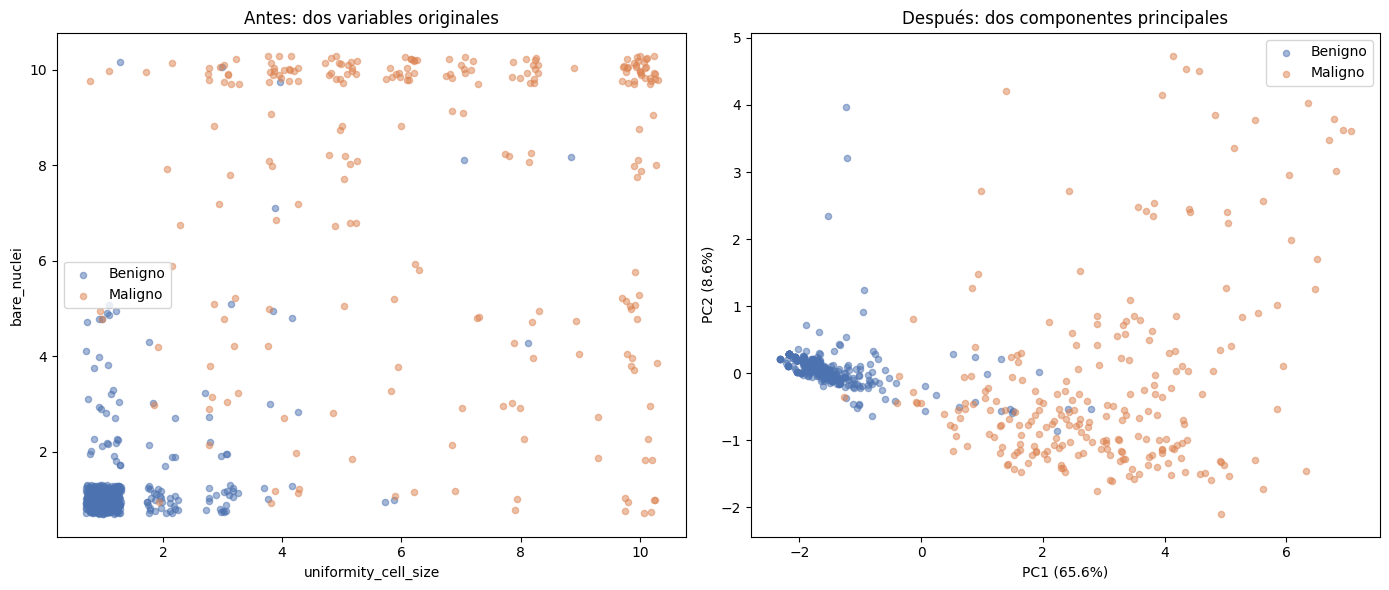

In [11]:
# Aplicamos PCA conservando solo 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_esc)

# Convertimos el resultado en DataFrame para usarlo después con SMOTE
X_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)

# Colores y nombres fijos por clase, para que no dependan del orden de los datos
colores = {0: "#4C72B0", 1: "#DD8452"}
nombres = {0: "Benigno", 1: "Maligno"}

# Números aleatorios con semilla fija para que el resultado sea reproducible
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for clase in [0, 1]:
    # Seleccionamos solo los pacientes de esta clase
    mascara = y == clase
    n = mascara.sum()

    # ANTES: dos variables originales, con un pequeño desplazamiento aleatorio (jitter)
    # para que los puntos con valores idénticos no queden encimados
    axes[0].scatter(X.loc[mascara, "uniformity_cell_size"] + rng.uniform(-0.3, 0.3, n),
                    X.loc[mascara, "bare_nuclei"] + rng.uniform(-0.3, 0.3, n),
                    c=colores[clase], label=nombres[clase], alpha=0.5, s=20)

    # DESPUÉS: los dos primeros componentes principales
    axes[1].scatter(X_pca.loc[mascara, "PC1"], X_pca.loc[mascara, "PC2"],
                    c=colores[clase], label=nombres[clase], alpha=0.5, s=20)

axes[0].set_title("Antes: dos variables originales")
axes[0].set_xlabel("uniformity_cell_size")
axes[0].set_ylabel("bare_nuclei")
axes[0].legend()

# Los ejes de PCA muestran el porcentaje de varianza que explica cada componente
axes[1].set_title("Después: dos componentes principales")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].legend()

plt.tight_layout()
plt.show()

Como los datos originales tienen 9 variables, no se pueden graficar todas al mismo tiempo. Por eso, para el "antes" usé las dos variables que más se relacionan con el diagnóstico: `uniformity_cell_size` y `bare_nuclei`. A los puntos les agregué un pequeño movimiento aleatorio (*jitter*) solo para que se vieran mejor, porque como los valores son números enteros del 1 al 10, muchos pacientes caen exactamente en el mismo punto y se enciman.

En la gráfica de antes, las clases sí se separan bastante, pero muchos pacientes quedan amontonados en pocas posiciones y hay casos malignos mezclados con los benignos.

En la gráfica de después, que junta la información de las 9 variables en solo dos componentes (y conserva el 74.2 % de la información), los casos benignos quedan agrupados en una zona compacta y los malignos se ven más dispersos. La separación entre las dos clases se da casi toda sobre el eje horizontal (PC1), lo que indica que ese primer componente es el que mejor distingue entre benigno y maligno.

Para entender qué representan PC1 y PC2, revisé las **cargas** (*loadings*): el peso que tiene cada variable original dentro de cada componente. Algunos detalles del código:

- `pca.components_` guarda los pesos que calculó PCA. Vienen con los componentes como filas, así que los transpuse con `.T` para que cada variable quede como una fila y la tabla sea más fácil de leer.
- Usé `barh` para hacer barras horizontales, porque los nombres de las variables son largos y así se leen mejor.
- Con `sharey=True` las dos gráficas comparten el eje de las variables, para poder comparar PC1 y PC2 renglón por renglón.
- `barh` dibuja de abajo hacia arriba, por eso las variables aparecen en orden inverso al de la tabla.

                              PC1   PC2
clump_thickness              0.30 -0.15
uniformity_cell_size         0.38 -0.05
uniformity_cell_shape        0.38 -0.08
marginal_adhesion            0.33 -0.05
single_epithelial_cell_size  0.34  0.17
bare_nuclei                  0.33 -0.25
bland_chromatin              0.35 -0.23
normal_nucleoli              0.34  0.02
mitoses                      0.23  0.91


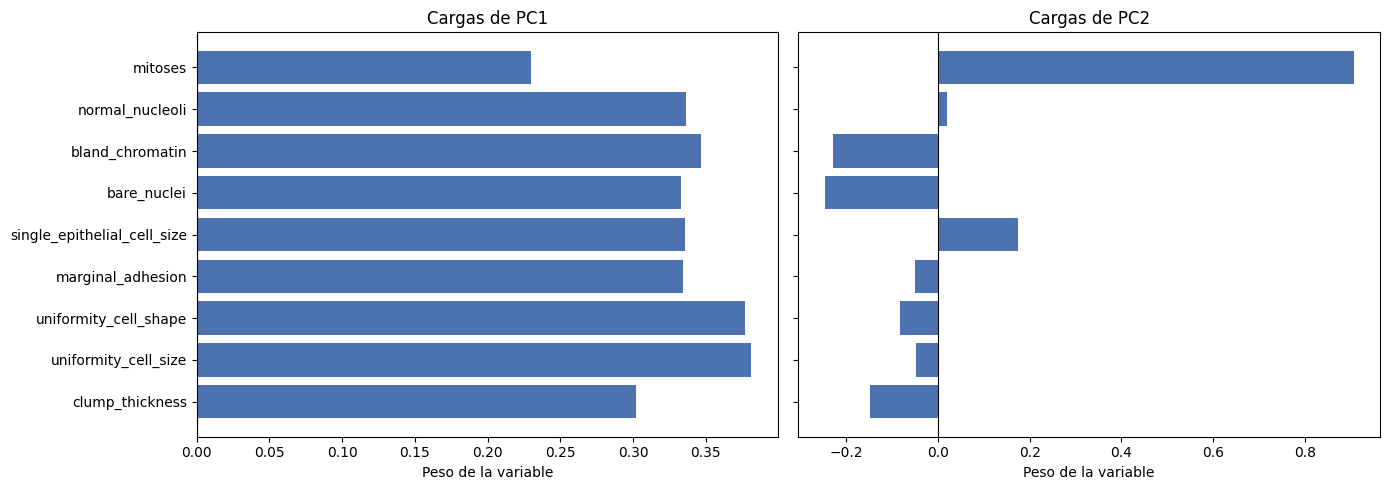

In [12]:
# Las cargas indican cuánto pesa cada variable original en cada componente
cargas = pd.DataFrame(pca.components_.T,
                      columns=["PC1", "PC2"],
                      index=variables)
print(cargas.round(2))

# Histogramas: una por componente
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, pc in zip(axes, ["PC1", "PC2"]):
    ax.barh(cargas.index, cargas[pc], color="#4C72B0")
    ax.axvline(0, color="black", linewidth=0.8)   # línea en cero como referencia
    ax.set_title(f"Cargas de {pc}")
    ax.set_xlabel("Peso de la variable")

plt.tight_layout()
plt.show()

En PC1 todas las variables pesan de forma parecida y en la misma dirección (entre 0.23 y 0.38). Esto quiere decir que PC1 es algo así como un promedio de todas las variables funciona como un "índice general de anormalidad" de las células. Un paciente con valores altos en casi todas las variables tendrá un PC1 alto. Por eso este componente separa de manera eficiente a los benignos de los malignos.

PC2, en cambio, depende casi solo de `mitoses` (peso de 0.91). Esto coincide con lo que vimos en la matriz de correlación: `mitoses` era la variable menos relacionada con las demás, así que PC1 no la resumía bien y PC2 se queda con esa información. Como `mitoses` era además la variable que menos ayudaba a distinguir el diagnóstico, PC2 aporta poco a la separación entre clases.

## Aumento de datos con SMOTE

En el análisis exploratorio vimos que las clases están desbalanceadas: hay 453 casos benignos y solo 238 malignos, casi dos a uno. Si se entrenara un modelo con estos datos podría "acostumbrarse" a responder benigno, y en un diagnóstico de cáncer el peor error es decirle benigno a alguien que tiene un tumor maligno.

Con la técnica SMOTE (*Synthetic Minority Over-sampling Technique*) crearemos pacientes sintéticos de la clase minoritaria. Así se aumentan los casos malignos hasta igualar a los benignos.

Para cada paciente sintético:

1. Elige al azar un paciente maligno real.
2. Busca sus 5 vecinos malignos más cercanos (5 es el valor por defecto).
3. Elige uno de esos vecinos al azar.
4. Crea un punto nuevo en la línea que une a los dos, en una posición aleatoria entre ellos.


In [13]:
# importamos SMOTE usando la biblioteca imbalanced-learn
from imblearn.over_sampling import SMOTE

# Se crea el objeto SMOTE con semilla fija para que los resultados sean reproducibles
smote = SMOTE(random_state=42)

# Generamos los datos balanceados a partir de los datos estandarizados
X_smote, y_smote = smote.fit_resample(X_esc, y)

# Verificamos los cambios
print("Antes:", X_esc.shape, "| Después:", X_smote.shape)
print("\nClases antes:\n", y.value_counts())
print("\nClases después:\n", y_smote.value_counts())
print("\nPacientes sintéticos creados:", len(X_smote) - len(X_esc))

Antes: (691, 9) | Después: (906, 9)

Clases antes:
 class
0    453
1    238
Name: count, dtype: int64

Clases después:
 class
0    453
1    453
Name: count, dtype: int64

Pacientes sintéticos creados: 215


La técnica SMOTE generó 215 pacientes malignos sintéticos, ahora las dos clases quedaron en 453 casos cada una y el dataset pasó de 691 a 906 registros. Los casos benignos no se modificaron.

Se aplicó SMOTE sobre los datos estandarizados porque, igual que PCA, SMOTE trabaja con distancias entre pacientes para encontrar a los vecinos más parecidos, y así evito que alguna variable pese más solo por su escala.


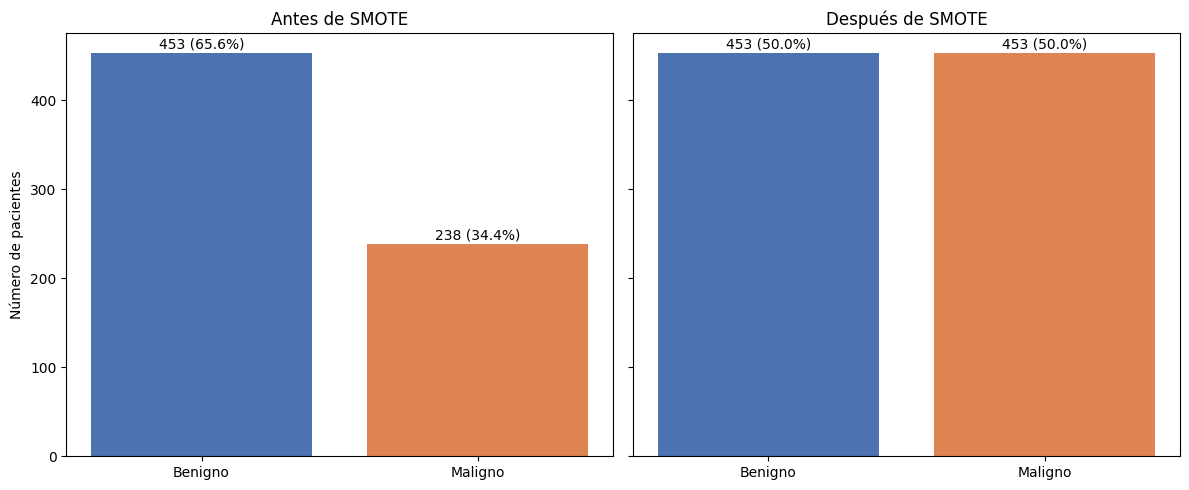

In [14]:
# Colores y nombres fijos por clase (ya definidos en el 4.3; se repiten por claridad)
colores = {0: "#4C72B0", 1: "#DD8452"}
nombres = {0: "Benigno", 1: "Maligno"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Recorremos los dos casos: antes (y) y después (y_smote)
for ax, datos, titulo in zip(axes, [y, y_smote], ["Antes de SMOTE", "Después de SMOTE"]):

    # Contamos pacientes por clase, siempre en el orden 0 y luego 1
    conteo = datos.value_counts().sort_index()

    # Dibujamos las barras con el color asignado a cada clase
    ax.bar([nombres[c] for c in conteo.index], conteo.values,
           color=[colores[c] for c in conteo.index])

    # Escribimos el conteo y el porcentaje sobre cada barra
    for i, v in enumerate(conteo.values):
        ax.text(i, v + 5, f"{v} ({v / len(datos):.1%})", ha="center")

    ax.set_title(titulo)

axes[0].set_ylabel("Número de pacientes")
plt.tight_layout()
plt.show()

Antes de aplicar SMOTE había casi dos casos benignos por cada maligno, un 65.6 % contra 34.4 %. Después, las dos clases quedaron exactamente iguales, con 453 casos cada una (50 % y 50 %).

Como se ve en la gráfica, la barra de los benignos no cambia. SMOTE no elimina ni modifica datos existentes, solo agrega pacientes malignos sintéticos hasta igualar las clases. Usé el mismo eje vertical en ambas gráficas para que la diferencia de tamaño se pueda comparar directamente.

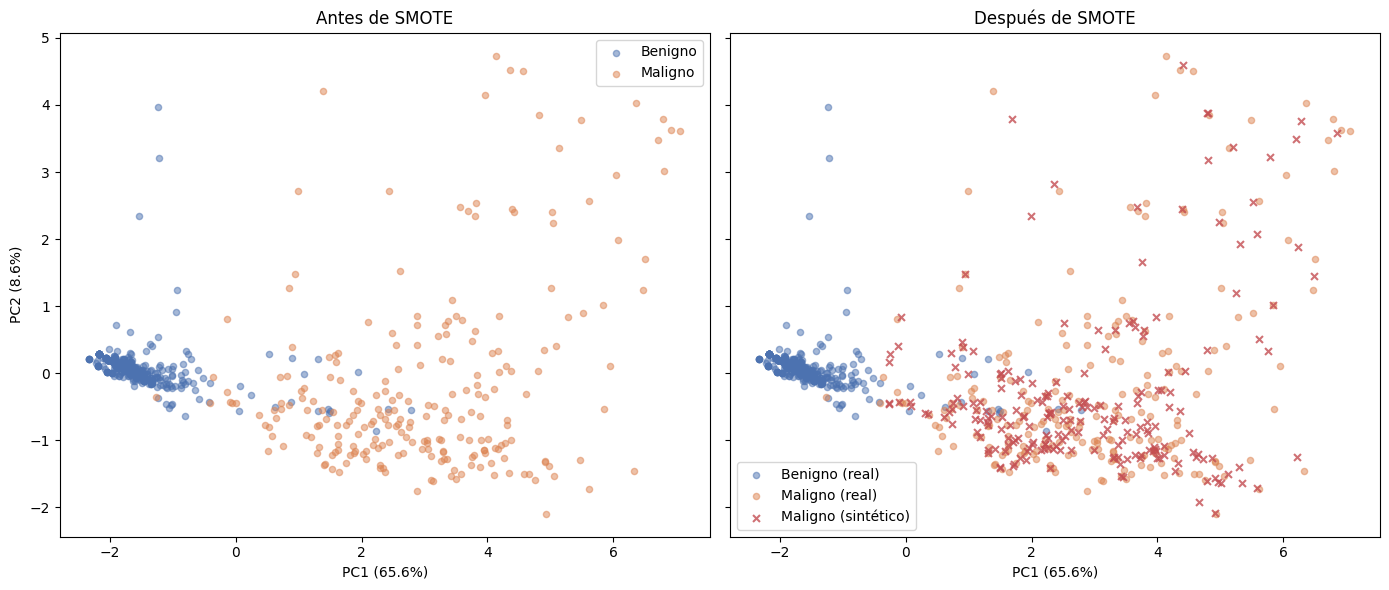

In [15]:
# Proyectamos los datos balanceados en el MISMO espacio de PCA del paso 4
X_smote_pca = pd.DataFrame(pca.transform(X_smote), columns=["PC1", "PC2"])

# Las primeras filas son los pacientes reales las últimas, los sintéticos
n_reales = len(X_esc)
es_sintetico = np.arange(len(X_smote)) >= n_reales
es_real = ~es_sintetico

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ANTES: solo pacientes reales
for clase in [0, 1]:
    mascara = y == clase
    axes[0].scatter(X_pca.loc[mascara, "PC1"], X_pca.loc[mascara, "PC2"],
                    c=colores[clase], label=nombres[clase], alpha=0.5, s=20)

# DESPUÉS: pacientes reales con los mismos colores
for clase in [0, 1]:
    mascara = (y_smote.values == clase) & es_real
    axes[1].scatter(X_smote_pca.loc[mascara, "PC1"], X_smote_pca.loc[mascara, "PC2"],
                    c=colores[clase], label=f"{nombres[clase]} (real)", alpha=0.5, s=20)


axes[1].scatter(X_smote_pca.loc[es_sintetico, "PC1"], X_smote_pca.loc[es_sintetico, "PC2"],
                c="#C44E52", marker="x", label="Maligno (sintético)", alpha=0.8, s=25)

axes[0].set_title("Antes de SMOTE")
axes[1].set_title("Después de SMOTE")
for ax in axes:
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.legend()
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

plt.tight_layout()
plt.show()

Para ver dónde quedaron los pacientes sintéticos, los proyecté en el mismo espacio de PCA del paso anterior. Se usó `transform` y no `fit_transform` para que los componentes fueran exactamente los mismos y las dos gráficas se pudieran comparar.

Los 215 pacientes sintéticos que se pueden identificar, porque están marcados con X, quedaron dentro de la zona que ya ocupaban los malignos reales, con una posición promedio y una dispersión muy parecidas. Ninguno apareció en medio del grupo de benignos. De alguna manera SMOTE "rellenó" la zona de los malignos con más puntos, pero no cambió la forma de los datos ni la separación entre clases.

## Conclusiones

En este trabajo usé el dataset *Breast Cancer Wisconsin* para aplicar las técnicas de reducción de dimensionalidad con PCA y aumento de datos con SMOTE.

**Limpieza de datos**

Antes de aplicar cualquier técnica fue necesario preparar los datos: eliminé 8 registros duplicados y la columna `id`, rellené con la mediana los 16 valores faltantes de `bare_nuclei` y cambié la clase a 0 = benigno y 1 = maligno. Al final quedaron 691 pacientes y 9 variables, sin datos faltantes.

**Lo que mostró el análisis exploratorio**

Las variables distinguen bien entre benignos y malignos, pero ninguna lo hace perfectamente por sí sola. Los benignos se parecen mucho entre sí y se concentran en valores bajos, mientras que los malignos están repartidos en toda la escala. Además, las variables están muy relacionadas entre sí (hasta 0.91), y las clases están desbalanceadas (casi dos benignos por cada maligno). Estos dos hallazgos fueron los que justificaron usar PCA y SMOTE.

**PCA**

PCA confirmó la redundancia que vimos en el análisis exploratorio. El primer componente, por sí solo, explica el 65.6 % de la variación, y los dos primeros el 74.2 %. Al revisar las cargas, vimos que PC1 funciona como un "índice general de anormalidad" porque todas las variables pesan de forma parecida en él. Al graficar los datos con dos componentes, los benignos y malignos se separan casi por completo sobre PC1, lo que muestra que es posible resumir 9 variables en 2 sin perder la información más importante para distinguir el diagnóstico.

**SMOTE**

SMOTE generó 215 pacientes malignos sintéticos y dejó las clases en 453 y 453. Al ubicarlos en el espacio de PCA, vimos que los sintéticos quedaron dentro de la zona que ya ocupaban los malignos reales, SMOTE agregó más casos en esa región, pero no cambió la forma de los datos ni la separación entre clases.

**Cómo se complementaron las técnicas**

Las técnicas no funcionaron por separado: la limpieza fue necesaria para poder aplicar las otras dos, y PCA fue lo que permitió ver en dos dimensiones el efecto de SMOTE, que de otra forma habría ocurrido en 9 dimensiones imposibles de graficar.

**Limitaciones**

- Los 16 valores faltantes se rellenaron con 1, que es el valor típico de un paciente benigno, aunque en los malignos la mediana de `bare_nuclei` es 10. Si alguno de esos pacientes era maligno, su valor quedó subestimado.
- Usé la correlación de Pearson, que supone variables continuas, en variables que en realidad son escalas del 1 al 10. La correlación de Spearman habría sido más adecuada.
- Al quedarme con dos componentes, se pierde el 25.8 % de la variación de los datos.
- Todos los pacientes sintéticos tienen valores con decimales (por ejemplo, 8.31), aunque la escala original solo permite enteros, así que no corresponden a pacientes que pudieran existir tal cual.
- Apliqué SMOTE a todo el dataset porque el objetivo era visualizarlo. Si se entrenara un modelo. SMOTE solo debería aplicarse a los datos de entrenamiento.

## Declaración de uso de IA

Para la elaboración de esta tarea se utilizó un asistente de inteligencia artificial (Claude, de Anthropic) como herramienta de apoyo. A continuación se detalla, con transparencia, en qué consistió ese apoyo:

**En qué me apoyó la IA:**

- Me guió paso a paso en la estructura del trabajo: carga, limpieza, análisis exploratorio, PCA y SMOTE.
- Me propuso el código de cada sección y me explicó qué hacía cada línea.
- Me ayudó a entender conceptos que no tenía claros, como el uso de `na_values`, la estandarización, la varianza explicada, las cargas de PCA y el funcionamiento de SMOTE.
- Me ayudó a resolver errores de ejecución, como el causado por ejecutar la limpieza dos veces.
- Me ayudó a encontrar errores ortográficos en las redacciones hechas por mi.

**Lo que hice yo:**

- Ejecuté todo el código en mi notebook y verifiqué que los resultados coincidieran con lo esperado.
- Hice preguntas sobre cada paso hasta entender por qué se hacía, y cuestioné algunas explicaciones.
- Revisé y ajusté los textos para que estuvieran en mis propias palabras.
- Tomé decisiones sobre la presentación, como usar una gráfica de varianza más sencilla.

Considero que la IA funcionó como una guía y apoyo para entender el proceso, y que puedo explicar cada paso y decisión del trabajo.